# Module 5 / Track A2 — Features on *your* fan dataset

Same recipe as `01_wisdm_features.ipynb`, applied to the 5-class fan dataset you recorded in Module 4 — **plus the spectral features** (FFT, 1× RPM fundamental, band energies) that the WISDM notebook skipped.

**Get your data:** in Edge Impulse Studio → *Data acquisition* → select all → **⋮ → Export data (JSON)** (or *Dashboard → Export*). Unzip into `./Data/fan/` so you have one `.json` file per recording, named like `imbalance.2c3f...json`. A CSV loader is provided as a fallback (EI can also export CSV: `timestamp,accX,accY,accZ`).

In [13]:
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
sns.set_style('whitegrid')

FS = 250.0          # Hz — must match your Module 4 recordings
DATA_DIR = './Data/fan'

## 1. Load the Edge Impulse export
EI's JSON sample format: `payload.values` is a list of `[accX, accY, accZ]` rows, `payload.interval_ms` gives the sample period, and the **label is the filename prefix** (up to the first dot).

In [14]:
def load_ei_json(path):
    """One EI JSON sample file -> (label, DataFrame[accX, accY, accZ])."""
    with open(path) as f:
        doc = json.load(f)
    values = np.array(doc['payload']['values'], dtype=float)
    names = [s['name'] for s in doc['payload']['sensors']]
    label = os.path.basename(path).split('.')[0]
    return label, pd.DataFrame(values, columns=names)

def load_csv(path):
    """Fallback: CSV with header timestamp,accX,accY,accZ."""
    label = os.path.basename(path).split('.')[0]
    return label, pd.read_csv(path)[['accX', 'accY', 'accZ']]

recordings = []   # list of (label, df) — one per 20 s recording
for p in sorted(glob.glob(f'{DATA_DIR}/*.json')):
    recordings.append(load_ei_json(p))
for p in sorted(glob.glob(f'{DATA_DIR}/*.csv')):
    recordings.append(load_csv(p))

print(f'{len(recordings)} recordings')
pd.Series([lab for lab, _ in recordings]).value_counts()

5 recordings


blocked      1
imbalance    1
normal       1
off          1
scrape       1
Name: count, dtype: int64

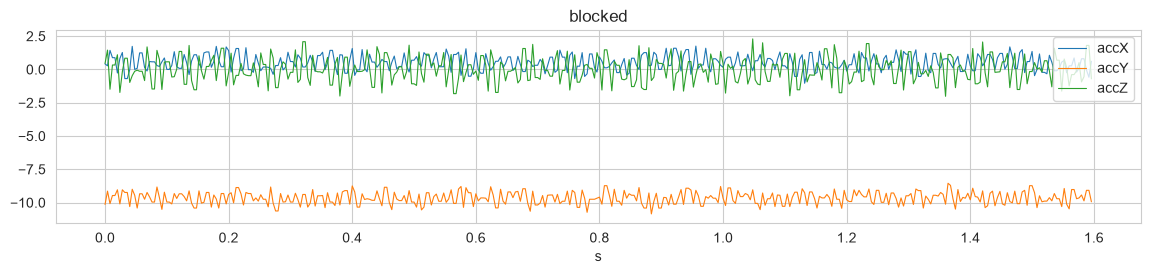

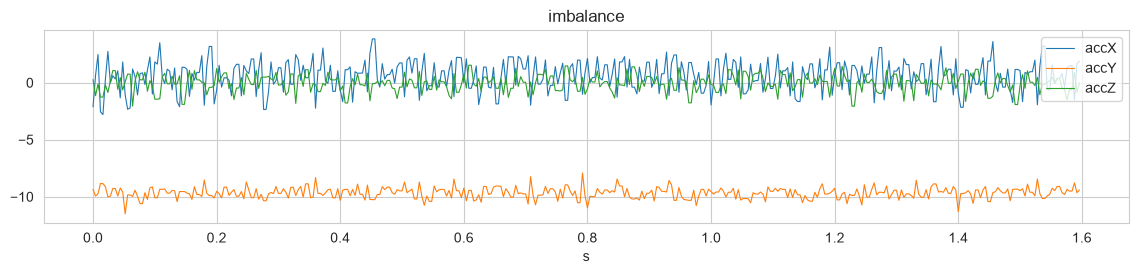

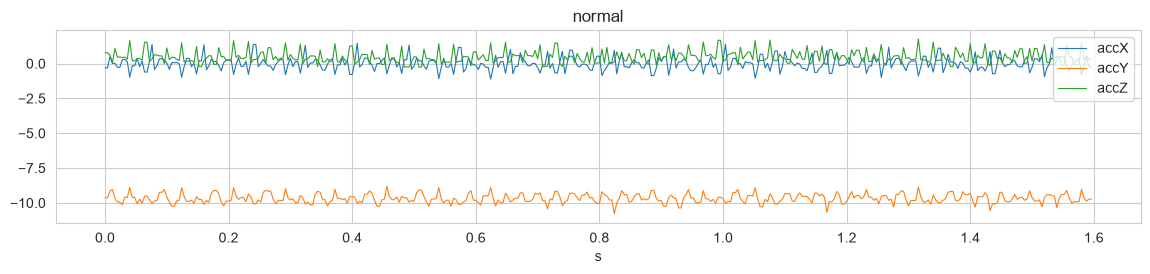

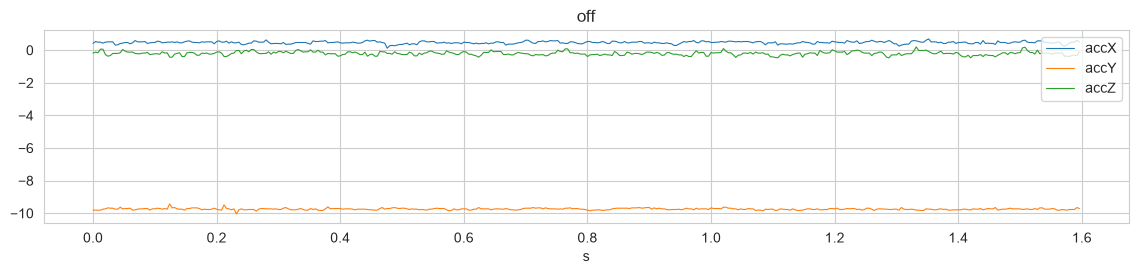

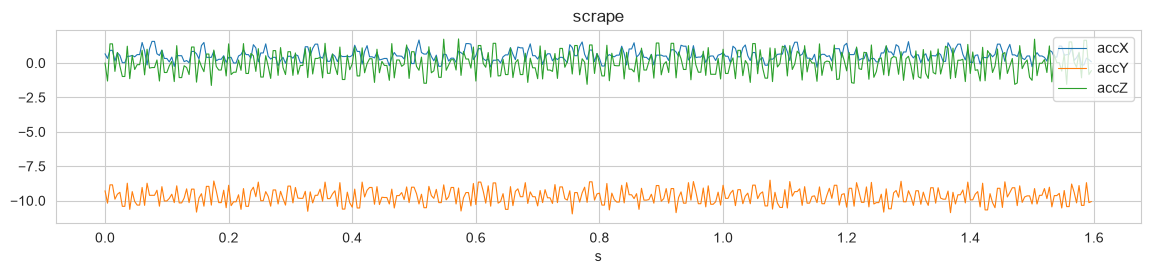

In [15]:
# One raw-data plot per class — the Module 4 eyeball check, now in pandas
seen = set()
for label, rec in recordings:
    if label in seen:
        continue
    seen.add(label)
    t = np.arange(len(rec)) / FS
    plt.figure(figsize=(14, 2.5))
    for ax in ['accX', 'accY', 'accZ']:
        plt.plot(t[:400], rec[ax].values[:400], label=ax, lw=0.8)
    plt.title(label); plt.xlabel('s'); plt.legend(loc='upper right'); plt.show()

## 2. Windowing
500 samples @ 250 Hz = 2 s windows, 50 % overlap — matching the EI impulse from Module 4. Windows never cross recording boundaries (that's the leakage rule again).

In [16]:
WIN, STEP = 500, 250

windows = []   # (label, wx, wy, wz)
for label, rec in recordings:
    for i in range(0, len(rec) - WIN, STEP):
        windows.append((label,
                        rec['accX'].values[i:i+WIN],
                        rec['accY'].values[i:i+WIN],
                        rec['accZ'].values[i:i+WIN]))

y_all = np.array([w[0] for w in windows])
print(len(windows), 'windows'); pd.Series(y_all).value_counts()

90 windows


blocked      18
imbalance    18
normal       18
off          18
scrape       18
Name: count, dtype: int64

## 3. Time-domain features
`axis_features` is copied verbatim from notebook 01 (same conventions — population std, zero-crossings around the mean) so results stay comparable with the C implementation in Track B.

In [17]:
def axis_features(w, prefix):
    w = np.asarray(w, dtype=float)
    mean = w.mean()
    return {
        f'{prefix}_mean': mean,
        f'{prefix}_std': w.std(),
        f'{prefix}_rms': np.sqrt(np.mean(w ** 2)),
        f'{prefix}_min': w.min(),
        f'{prefix}_max': w.max(),
        f'{prefix}_maxmin_diff': w.max() - w.min(),
        f'{prefix}_skewness': stats.skew(w),
        f'{prefix}_kurtosis': stats.kurtosis(w),
        f'{prefix}_energy': np.sum(w ** 2) / len(w),
        f'{prefix}_peak_count': len(find_peaks(w)[0]),
        f'{prefix}_zero_crossings': int(np.sum((w[:-1] - mean) * (w[1:] - mean) < 0)),
    }

## 4. NEW — the spectrum: find your fan's 1× RPM fundamental
Predict it first: `nominal RPM / 60` from your Module 4 `NOTES.md` (e.g. 1350 RPM → 22.5 Hz). Then look at the FFT of a `normal` window. A Hann window reduces spectral leakage.

Bin *k* ↔ frequency `k · FS / N`; with N=200 @ 100 Hz the resolution is 0.5 Hz.

Predicted fundamental: 22.5 Hz


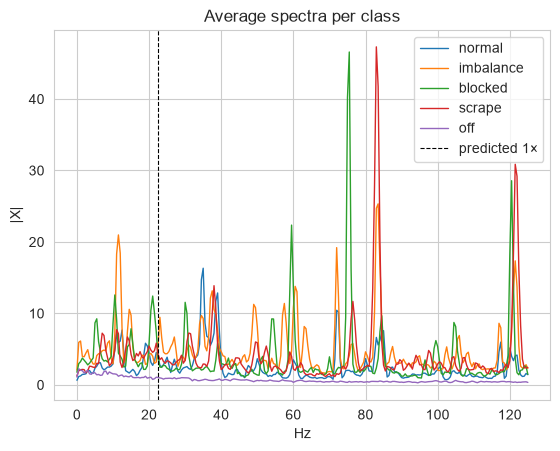

Measured fundamental ≈ 35.0 Hz  →  2100 RPM


In [18]:
NOMINAL_RPM = 1350          # <-- EDIT: from your NOTES.md
print(f'Predicted fundamental: {NOMINAL_RPM/60:.1f} Hz')

def spectrum(w, fs=FS):
    w = np.asarray(w, dtype=float)
    w = w - w.mean()                      # remove DC/gravity before looking at peaks
    X = np.fft.rfft(w * np.hanning(len(w)))
    freqs = np.fft.rfftfreq(len(w), d=1/fs)
    return freqs, np.abs(X)

for label in ['normal', 'imbalance', 'blocked', 'scrape', 'off']:
    idx = np.where(y_all == label)[0]
    if len(idx) == 0:
        continue
    # average magnitude spectrum over that class's windows (pick the liveliest axis)
    mags = np.mean([spectrum(windows[i][2])[1] for i in idx], axis=0)   # [2] = accY; try 1/2/3
    freqs = spectrum(windows[idx[0]][2])[0]
    plt.plot(freqs, mags, label=label, lw=1)
plt.axvline(NOMINAL_RPM/60, color='k', ls='--', lw=0.8, label='predicted 1×')
plt.xlabel('Hz'); plt.ylabel('|X|'); plt.legend(); plt.title('Average spectra per class')
plt.show()

# Where is the actual peak for 'normal'?
idx_n = np.where(y_all == 'normal')[0]
mags_n = np.mean([spectrum(windows[i][2])[1] for i in idx_n], axis=0)
peak_hz = freqs[np.argmax(mags_n[2:]) + 2]   # skip the lowest bins
print(f'Measured fundamental ≈ {peak_hz:.1f} Hz  →  {peak_hz*60:.0f} RPM')

**Checkpoint:** measured fundamental within ~10 % of the datasheet prediction. Note how `imbalance` boosts the 1× peak, `blocked` *shifts* it, `scrape` raises the floor everywhere, `off` is flat.

## 5. Band energies — the spectral features we deploy
5 bands × 10 Hz (0–50 Hz), per axis. Sum of |X|² per band, DC bin excluded. This exact definition (incl. the Hann window) is what the C implementation in Track B computes — keep them in sync.

In [19]:
N_BANDS = 5

def band_energies(w, prefix, fs=FS, n_bands=N_BANDS):
    w = np.asarray(w, dtype=float)
    X = np.fft.rfft(w * np.hanning(len(w)))
    freqs = np.fft.rfftfreq(len(w), d=1/fs)
    mag2 = np.abs(X) ** 2
    band_hz = (fs / 2) / n_bands
    out = {}
    for b in range(n_bands):
        sel = (freqs >= b * band_hz) & (freqs < (b + 1) * band_hz)
        sel[0] = False                      # exclude DC
        out[f'{prefix}_band{b}'] = mag2[sel].sum()
    return out

rows = []
for label, wx, wy, wz in windows:
    row = {}
    for w, p in [(wx, 'x'), (wy, 'y'), (wz, 'z')]:
        row.update(axis_features(w, p))
        row.update(band_energies(w, p))
    rows.append(row)
X_all = pd.DataFrame(rows)
print(X_all.shape)
X_all.head()

(90, 48)


,x_mean,x_std,x_rms,x_min,x_max,x_maxmin_diff,x_skewness,x_kurtosis,x_energy,x_peak_count,...,z_skewness,z_kurtosis,z_energy,z_peak_count,z_zero_crossings,z_band0,z_band1,z_band2,z_band3,z_band4
0,0.50496,0.575696,0.765774,-1.04,1.75,2.79,0.132140,-0.916774,0.586410,119,...,0.150920,-0.813690,0.958180,131,234,4136.015098,1911.475216,21794.232740,11226.681089,7042.523791
1,0.50882,0.572496,0.765931,-1.04,1.86,2.90,0.177957,-0.937291,0.586650,119,...,0.170302,-0.772391,0.977181,132,234,4252.849176,1937.062969,18975.760943,11258.496013,8372.437295
2,0.51552,0.581586,0.777176,-0.63,2.08,2.71,0.257902,-0.899135,0.604003,119,...,0.163662,-0.803650,0.972718,129,239,4761.529348,1827.310481,19035.674342,10833.440665,8132.147600
3,0.50490,0.590638,0.777031,-0.63,2.08,2.71,0.162566,-0.912951,0.603778,120,...,0.176639,-0.755789,0.917704,128,236,3018.707108,1724.971298,19787.964608,11464.581847,7086.549632
4,0.47596,0.584873,0.754065,-0.76,1.77,2.53,0.194095,-0.915118,0.568614,120,...,0.138153,-0.700767,0.878710,131,235,2717.647658,1633.073964,16267.979540,11510.984468,8002.367244


## 6. Which features separate which states?
Boxplots per class for the candidate deployment set.

**Why boxplots and not, say, the mean per class?** A classifier never sees a class average — it sees *one window at a time*. So the question is not "is `y_band2` higher for `blocked` than for `normal` on average?" but "if I am handed a single 2-s window and told only its `y_band2`, how often can I tell which state produced it?" That depends on the **spread within each class** as much as on the distance between classes, and a boxplot shows both at once. Each box is the distribution of one feature over all 18 windows of one class: line = median, box = middle 50 % (quartiles), whiskers = the bulk of the rest, dots = outlier windows.

**How to read them — three things, in this order:**

1. **Separation.** Do the boxes sit at different heights *and* fail to overlap? Two boxes side by side with clear air between them = that feature alone splits those two states. Boxes at the same height, or overlapping heavily, = the feature is blind to that pair. This is the eyeball version of the "between-class distance / within-class spread" ratio a decision tree optimises when it picks a split threshold.
2. **Which pair.** No single feature has to separate all five states — that is the model's job. What you are hunting for is a *set* that covers every pair: `y_rms` may isolate `off` from everything else while leaving `imbalance` vs `blocked` untouched, and `y_band1` may do exactly the reverse. Read the nine plots as a team, and note the pairs nobody separates — those are the confusions you should expect in the Module 7 confusion matrix, predicted before you train anything.
3. **Redundancy.** If two plots have the *same shape* — same ranking of classes, same relative gaps — the two features carry the same information, and paying for both on-device buys you nothing. `std` and `rms` are the classic pair here (identical whenever the window mean is ~0, i.e. gravity removed), and neighbouring band energies often track each other too. Keep one, drop the other; that is cheap accuracy per byte and per microsecond.

**What you expect to see** (from the spectra in §4): `off` collapses to near-zero on every energy-like feature and is the trivially separable class; `imbalance` lifts the band holding the 1× fundamental (at FS = 250 Hz the five bands are 25 Hz wide, so a ~22 Hz fundamental sits in `band0`); `scrape` raises the *high* bands and the kurtosis (impulsive contacts = heavy tails); `blocked` shifts energy between bands rather than adding it, so watch band *ratios* rather than absolute levels; `zero_crossings` tracks the dominant frequency and so follows RPM changes.

**Two cells, two axes:** the first cell plots the `y` axis, the second the `x` axis. Compare them and keep the *liveliest* axis — the one whose boxes are furthest apart relative to their height. Dropping two of three axes cuts your feature count (and FFT cost) by 3× for free, and that decision is what §7 asks you to write down.

**Caveats worth stating out loud.** These boxes come from overlapping windows out of a *single* recording per class, so they show within-recording variability only — re-mount the sensor, change the rig temperature or the fan's duty point and the boxes move. Real deployment spread is wider than what you see here, so treat "just barely separated" as "not separated". Also mind the y-axis scale: band energies span orders of magnitude, so a class can look pinned to zero purely because another class dominates the axis — add `plt.yscale('log')` to the plotting cell if a box is squashed flat.


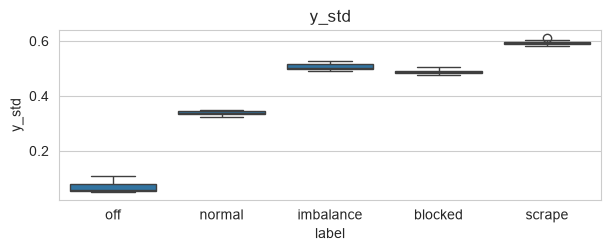

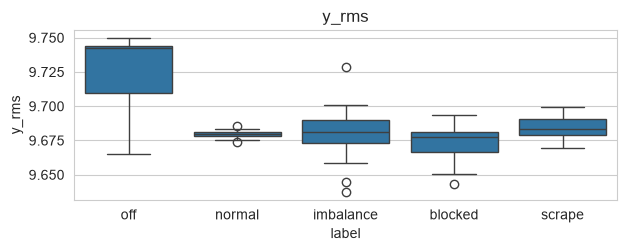

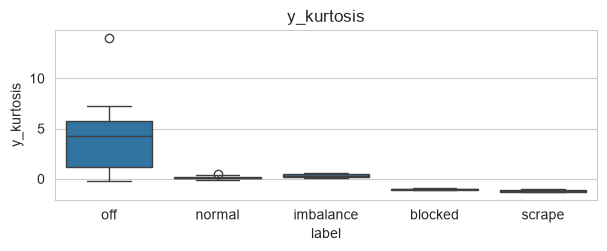

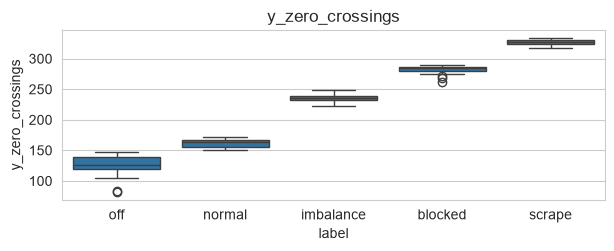

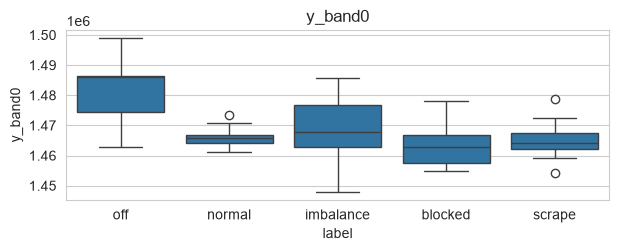

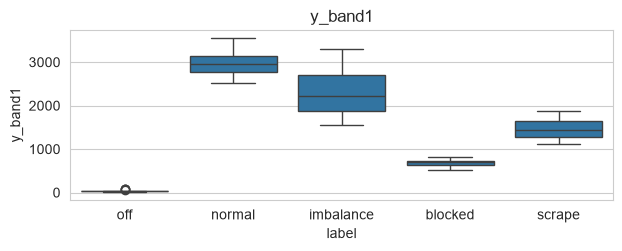

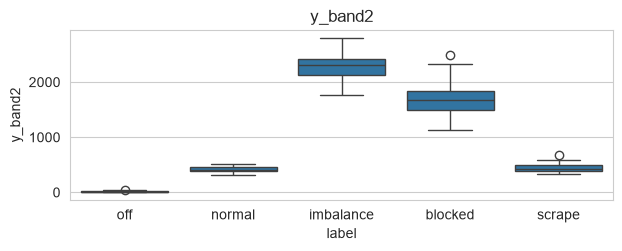

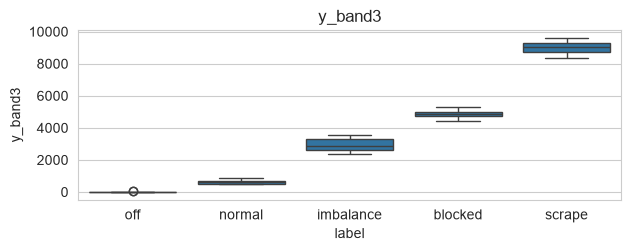

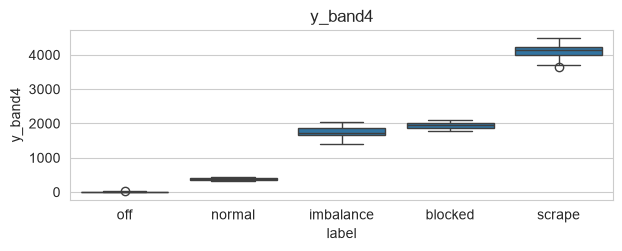

In [20]:
candidates = ['y_std', 'y_rms', 'y_kurtosis', 'y_zero_crossings',
              'y_band0', 'y_band1', 'y_band2', 'y_band3', 'y_band4']
plot_df = X_all[candidates].copy(); plot_df['label'] = y_all
for feat in candidates:
    plt.figure(figsize=(7, 2.2))
    sns.boxplot(x='label', y=feat, data=plot_df,
                order=['off', 'normal', 'imbalance', 'blocked', 'scrape'])
    plt.title(feat); plt.show()

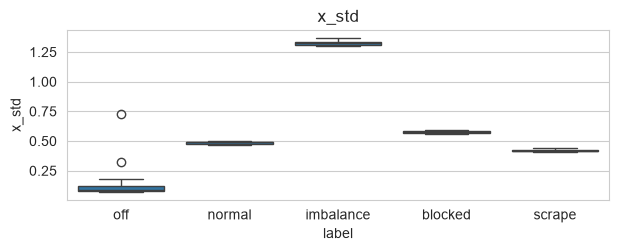

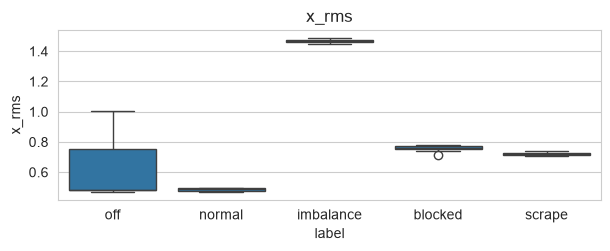

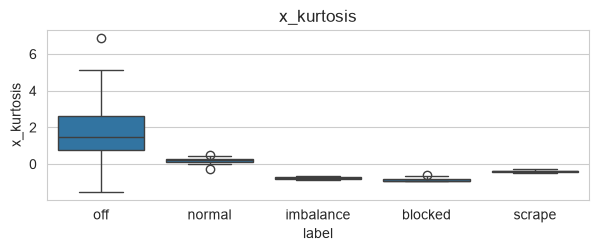

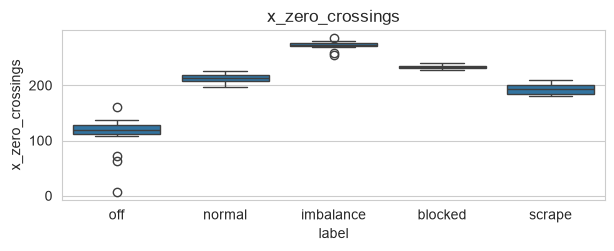

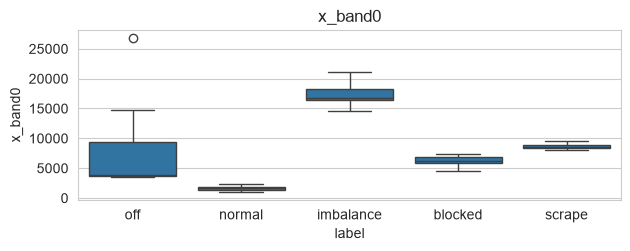

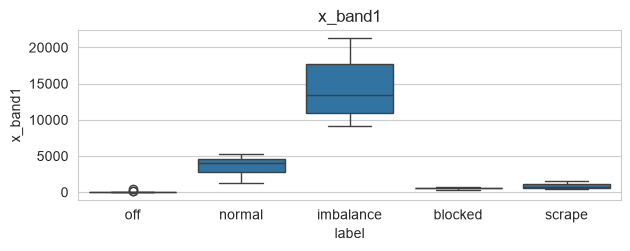

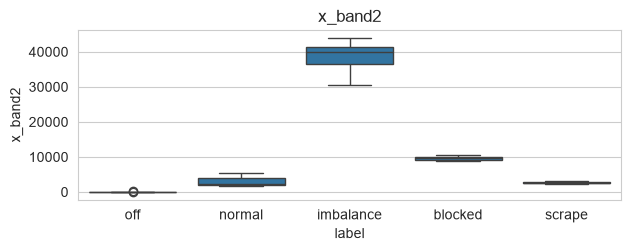

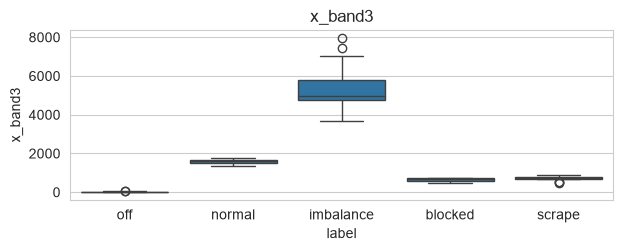

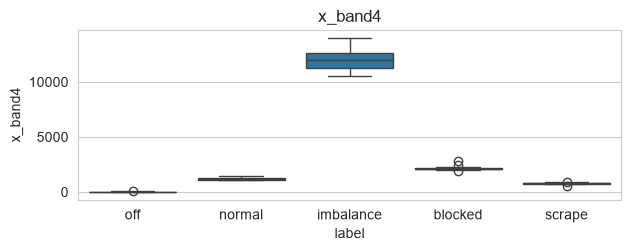

In [21]:
candidates = ['x_std', 'x_rms', 'x_kurtosis', 'x_zero_crossings',
              'x_band0', 'x_band1', 'x_band2', 'x_band3', 'x_band4']
plot_df = X_all[candidates].copy(); plot_df['label'] = y_all
for feat in candidates:
    plt.figure(figsize=(7, 2.2))
    sns.boxplot(x='label', y=feat, data=plot_df,
                order=['off', 'normal', 'imbalance', 'blocked', 'scrape'])
    plt.title(feat); plt.show()

5-fold CV accuracy: 0.989


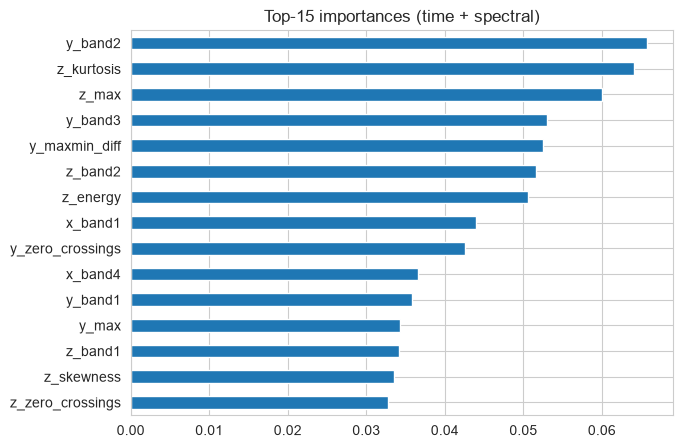

In [22]:
# Quick RF importance across time + spectral features (exploration only —
# the real train/test evaluation happens in Module 7 with the EI-held-out test set)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=15, random_state=21)
print('5-fold CV accuracy: %.3f' % cross_val_score(rf, X_all, y_all, cv=5).mean())
rf.fit(X_all, y_all)
pd.Series(rf.feature_importances_, index=X_all.columns) \
  .sort_values(ascending=False).head(15).plot.barh(figsize=(7, 5))
plt.gca().invert_yaxis(); plt.title('Top-15 importances (time + spectral)'); plt.show()

**Warning:** the CV score above is windows-level cross-validation and therefore optimistic (overlapping windows from the same recording land in different folds). It is fine for *ranking features*, not for quoting accuracy. Honest accuracy comes from the recording-level test split in EI (Module 7).

## 7. Decide your on-device feature set
Pick **3–7 features per axis** (or fewer axes!). For each, one line: *importance* (rank), *cost* (single pass / FFT / sort), *redundancy* (what it correlates with). Typical strong set: `std`, `rms`, `kurtosis`, `zero_crossings` + the 5 band energies, on the liveliest axis.

## 8. Export golden windows for the C validation (Track B)
One 512 //256-sample window per class → C arrays. 256 = the FFT size used on-device (we take 256 consecutive samples rather than zero-padding the 200-sample window).

In [23]:
def window_to_c_array(w, name, path):
    w = np.asarray(w, dtype=float)
    lines = [f'// generated by 02_fan_features.ipynb — golden window "{name}"',
             f'#pragma once',
             f'#define {name.upper()}_LEN {len(w)}',
             f'static const float {name}[{len(w)}] = {{']
    for i in range(0, len(w), 8):
        lines.append('    ' + ', '.join(f'{v:.6f}f' for v in w[i:i+8]) + ',')
    lines.append('};')
    with open(path, 'w') as f:
        f.write('\n'.join(lines) + '\n')
    # also save as CSV for the Python side of the validation
    np.savetxt(path.replace('.h', '.csv'), w, fmt='%.6f')
    print('wrote', path)

os.makedirs('../features-c/include/golden', exist_ok=True)
FFT_N = 512 #256
for label in ['normal', 'imbalance', 'blocked', 'scrape', 'off']:
    for lab, rec in recordings:
        if lab == label and len(rec) >= FFT_N:
            window_to_c_array(rec['accY'].values[:FFT_N], f'win_{label}',
                              f'../features-c/include/golden/win_{label}.h')
            break

wrote ../features-c/include/golden/win_normal.h
wrote ../features-c/include/golden/win_imbalance.h
wrote ../features-c/include/golden/win_blocked.h
wrote ../features-c/include/golden/win_scrape.h
wrote ../features-c/include/golden/win_off.h


→ Continue with **Track B** (`features-c/`): compute the same numbers in C on the RAK4631 and run `validate_features.py`.